In [5]:
# Menampilkan file yang diunggah
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import pickle
import io

In [6]:
df = pd.read_csv("Data Historis INDF.csv", delimiter=";")
# Drop unwanted unnamed columns if present
df = df[['Tanggal', 'Terakhir']]
# Show dataframe (verifikasi bahwa kolom Unnamed dihapus)
df

,Tanggal,Terakhir
0,23/10/15,6.225
1,26/10/15,6.225
2,27/10/15,6.200
3,28/10/15,6.075
4,29/10/15,5.650
...,...,...
2410,16/10/25,7.075
2411,17/10/25,7.125
2412,20/10/25,7.250
2413,21/10/25,7.275


In [7]:
# Menampilkan data
print("Historis Saham INDF:")
print(f"\nShape data: {df.shape}")
df

Historis Saham INDF:

Shape data: (2415, 2)


,Tanggal,Terakhir
0,23/10/15,6.225
1,26/10/15,6.225
2,27/10/15,6.200
3,28/10/15,6.075
4,29/10/15,5.650
...,...,...
2410,16/10/25,7.075
2411,17/10/25,7.125
2412,20/10/25,7.250
2413,21/10/25,7.275


In [8]:
# 1. Parsing Tanggal dengan format eksplisit (Menghilangkan UserWarning)
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d/%m/%y', errors='coerce')

# 2. Hapus jika ada baris yang gagal jadi tanggal (NaN)
df = df.dropna(subset=['Tanggal'])

# 3. Urutkan dan tangani duplikat
df = df.sort_values('Tanggal')
df = df.groupby('Tanggal')['Terakhir'].mean().reset_index()

# 4. Set Index
df.set_index('Tanggal', inplace=True)

# 5. Buat range weekday (freq='B')
all_weekdays = pd.date_range(start=df.index.min(), end=df.index.max(), freq='B')

# 6. Reindex
df = df.reindex(all_weekdays)

# 7. Interpolasi dan Backfill (Menghilangkan FutureWarning)
df['Terakhir'] = df['Terakhir'].interpolate(method='linear')
df['Terakhir'] = df['Terakhir'].bfill()

# 8. Reset Index
df = df.reset_index().rename(columns={'index': 'Tanggal'})

print("--- Data Cleaned! ---")
print("Range Tanggal:", df['Tanggal'].min(), "sampai", df['Tanggal'].max())
print("Missing values:", df['Terakhir'].isnull().sum())
print(df.head())

--- Data Cleaned! ---
Range Tanggal: 2015-10-23 00:00:00 sampai 2025-10-22 00:00:00
Missing values: 0
     Tanggal  Terakhir
0 2015-10-23     6.225
1 2015-10-26     6.225
2 2015-10-27     6.200
3 2015-10-28     6.075
4 2015-10-29     5.650


In [9]:
df.head(10)

,Tanggal,Terakhir
0,2015-10-23,6.225
1,2015-10-26,6.225
2,2015-10-27,6.200
3,2015-10-28,6.075
4,2015-10-29,5.650
5,2015-10-30,5.525
6,2015-11-02,5.825
7,2015-11-03,5.825
8,2015-11-04,6.100
9,2015-11-05,6.000


In [10]:
# ===============================
# VALIDASI DATA (CEK WEEKDAY & WEEKEND)
# ===============================

# 1. Cek apakah ada missing value (NaN)
missing_count = df['Terakhir'].isnull().sum()

# 2. Cek apakah ada hari Sabtu (5) atau Minggu (6)
# dayofweek: 0=Senin, 4=Jumat, 5=Sabtu, 6=Minggu
weekend_data = df[df['Tanggal'].dt.dayofweek >= 5]

# 3. Cek kesinambungan tanggal (apakah ada weekday yang terlewat)
# Kita bandingkan dengan range bisnis hari yang seharusnya
expected_range = pd.date_range(start=df['Tanggal'].min(), end=df['Tanggal'].max(), freq='B')
is_complete = len(df) == len(expected_range)

print("--- HASIL VALIDASI ---")
print(f"1. Jumlah Missing Value: {missing_count}")
print(f"2. Jumlah data Weekend (Sabtu/Minggu): {len(weekend_data)}")
print(f"3. Apakah jumlah baris sudah sesuai dengan kalender bisnis? {'YA' if is_complete else 'TIDAK'}")

if len(weekend_data) > 0:
    print("⚠️ Peringatan: Masih ada data weekend!")
else:
    print("✅ Aman: Tidak ada weekend di dalam dataset.")

if missing_count == 0 and is_complete:
    print("✅ Aman: Semua weekday telah terisi penuh tanpa ada yang keskip.")

--- HASIL VALIDASI ---
1. Jumlah Missing Value: 0
2. Jumlah data Weekend (Sabtu/Minggu): 0
3. Apakah jumlah baris sudah sesuai dengan kalender bisnis? YA
✅ Aman: Tidak ada weekend di dalam dataset.
✅ Aman: Semua weekday telah terisi penuh tanpa ada yang keskip.


In [11]:
# Normalize and parse date column (handle different possible column names)
date_col = None
for c in ['Tanggal', 'tanggal', 'Date', 'date']:
    if c in df.columns:
        date_col = c
        break
if date_col is None:
    raise KeyError('No date column found. Expected one of: Tanggal, tanggal, Date, date')
# Robust parsing: try common formats first, then fallback to generic parser
date_series = df[date_col].astype(str).str.strip()
formats = ['%d/%m/%Y', '%Y-%m-%d', '%d-%m-%Y', '%d %b %Y', '%d %B %Y']
final_parsed = pd.Series([pd.NaT] * len(date_series))
for fmt in formats:
    parsed = pd.to_datetime(date_series, format=fmt, dayfirst=True, errors='coerce')
    final_parsed = final_parsed.combine_first(parsed)
if final_parsed.isna().any():
    remaining_idx = final_parsed.isna()
    final_parsed.loc[remaining_idx] = pd.to_datetime(date_series[remaining_idx], dayfirst=True, errors='coerce')
df[date_col] = final_parsed
# Rename to consistent column name 'Tanggal'
if date_col != 'Tanggal':
    df = df.rename(columns={date_col: 'Tanggal'})
# Ensure price column is named 'Terakhir' (handle possible variants)
price_col = None
for c in ['Terakhir', 'terakhir', 'Close', 'close']:
    if c in df.columns:
        price_col = c
        break
if price_col is None:
    raise KeyError('No price column found. Expected one of: Terakhir, terakhir, Close, close')
if price_col != 'Terakhir':
    df = df.rename(columns={price_col: 'Terakhir'})
# Sort by the normalized date column
df = df.sort_values('Tanggal')

In [12]:
df = df.sort_values('Tanggal')
data = df.set_index('Tanggal')
data

,Terakhir
Tanggal,
2015-10-23,6.225
2015-10-26,6.225
2015-10-27,6.200
2015-10-28,6.075
2015-10-29,5.650
...,...
2025-10-16,7.075
2025-10-17,7.125
2025-10-20,7.250


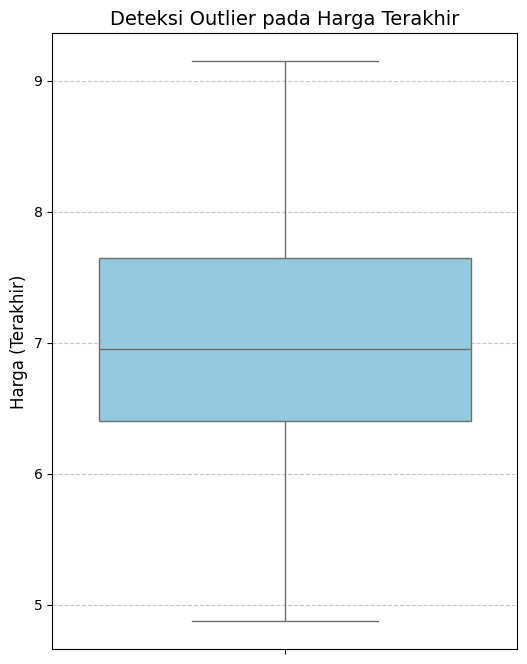

Batas Bawah: 4.525
Batas Atas: 9.525
Jumlah data outlier: 0


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# DETEKSI OUTLIER DENGAN BOXPLOT
# ===============================
plt.figure(figsize=(6, 8)) # Dibalik jadi (lebar, tinggi) agar lebih enak dilihat secara vertikal

# Cukup ganti x jadi y di sini
sns.boxplot(y=data['Terakhir'], color='skyblue')

plt.title('Deteksi Outlier pada Harga Terakhir', fontsize=14)
plt.ylabel('Harga (Terakhir)', fontsize=12) # Ganti label jadi sumbu y
plt.grid(axis='y', linestyle='--', alpha=0.7) # Grid disesuaikan ke sumbu y
plt.show()

# --- Perhitungan IQR tetap sama ---
Q1 = data['Terakhir'].quantile(0.25)
Q3 = data['Terakhir'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['Terakhir'] < lower_bound) | (data['Terakhir'] > upper_bound)]
print(f"Batas Bawah: {lower_bound}")
print(f"Batas Atas: {upper_bound}")
print(f"Jumlah data outlier: {len(outliers)}")

In [14]:
# Deskripsi data yang digunakan
print("Deskripsi Data:")
print(data.describe())

Deskripsi Data:
          Terakhir
count  2609.000000
mean      7.019104
std       0.792604
min       4.875000
25%       6.400000
50%       6.950000
75%       7.650000
max       9.150000


In [15]:
# Cek missing values
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
Terakhir    0
dtype: int64


In [16]:
# Cek tanggal duplikat
data = data.groupby('Tanggal').mean().reset_index()

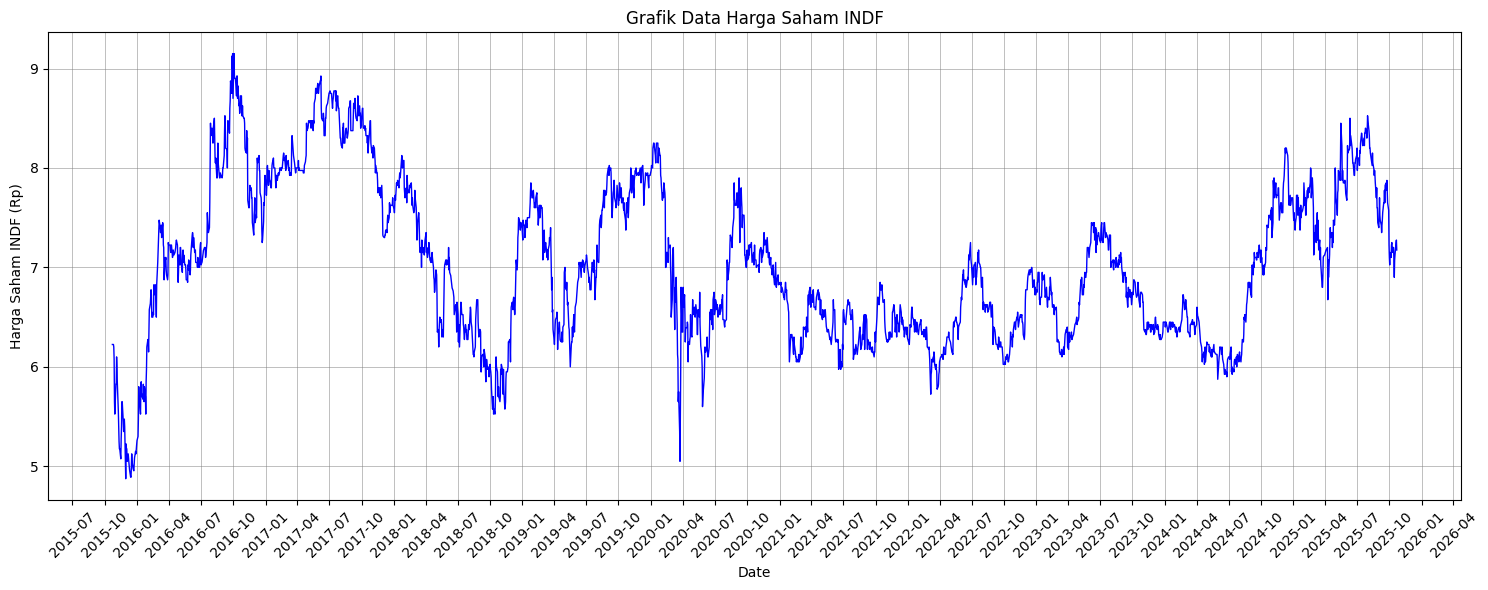

In [17]:
"""#Grafik Data"""

# Membuat plot data
plt.figure(figsize=(15,6))
plt.plot(data['Tanggal'], data['Terakhir'], color='blue', linewidth=1)

# Menambahkan judul dan label sumbu
plt.title('Grafik Data Harga Saham INDF')
plt.xlabel('Date')
plt.ylabel('Harga Saham INDF (Rp)')

# Atur sumbu x agar mudah dibaca
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Menampilkan tanggal setiap 3 bulan
plt.xticks(rotation=45)
plt.tight_layout()

# Menambahkan grid
plt.grid(True, linestyle='-', linewidth=0.5, color='gray', alpha=0.7)

# Menampilkan plot
plt.show()

In [18]:
!pip install keras-tcn


🔥 KOMBINASI 0.6-0.2-0.2
Train: (1558, 12, 1), Val: (519, 12, 1), Test: (520, 12, 1)
Total kombinasi: 16

➡️ Kombinasi 1
MAPE TEST: 1.41%

➡️ Kombinasi 2
MAPE TEST: 1.09%

➡️ Kombinasi 3
MAPE TEST: 1.16%

➡️ Kombinasi 4
MAPE TEST: 1.09%

➡️ Kombinasi 5
MAPE TEST: 1.22%

➡️ Kombinasi 6
MAPE TEST: 1.08%

➡️ Kombinasi 7
MAPE TEST: 1.19%

➡️ Kombinasi 8
MAPE TEST: 1.09%

➡️ Kombinasi 9
MAPE TEST: 1.32%

➡️ Kombinasi 10
MAPE TEST: 1.34%

➡️ Kombinasi 11
MAPE TEST: 1.41%

➡️ Kombinasi 12
MAPE TEST: 1.20%

➡️ Kombinasi 13
MAPE TEST: 1.40%

➡️ Kombinasi 14
MAPE TEST: 1.13%

➡️ Kombinasi 15
MAPE TEST: 1.27%

➡️ Kombinasi 16
MAPE TEST: 1.15%

🏆 BEST PARAMS: (32, 3, (1, 2, 4), 32, 0.1, 16, 0.0001)
BEST MAPE TEST: 1.08%
⏱️ Waktu Split 0.6-0.2-0.2: 507.49 detik


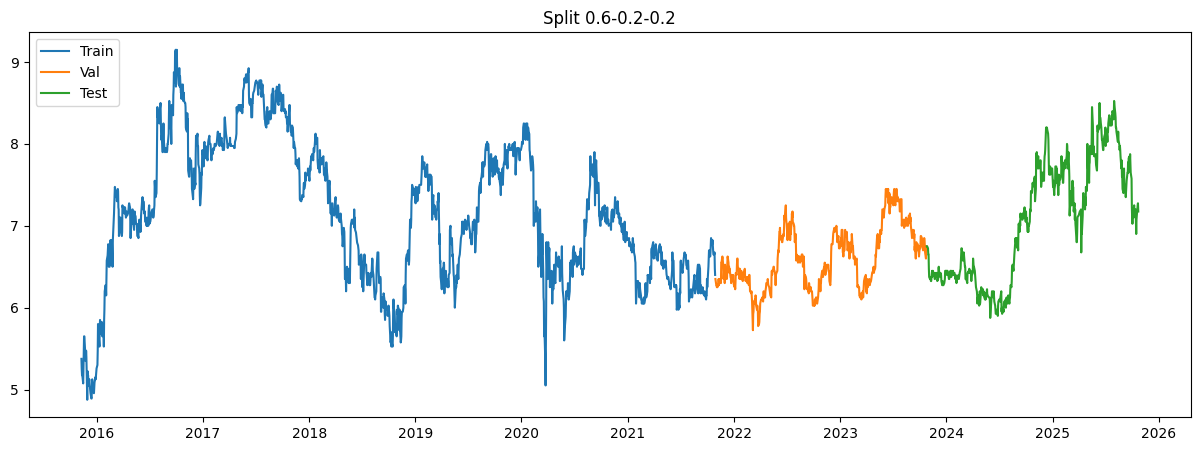

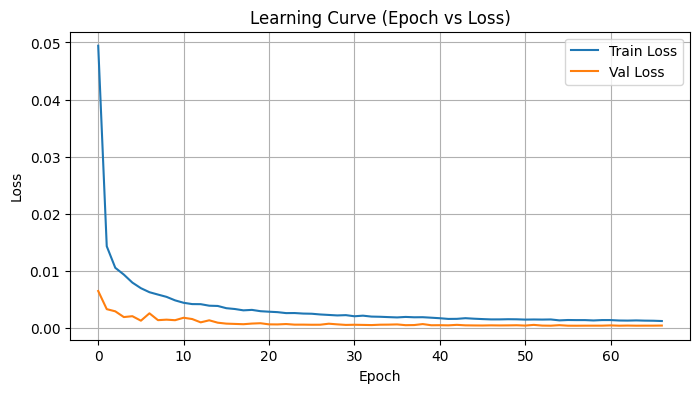

Best epoch: 57

🔥 KOMBINASI 0.7-0.15-0.15
Train: (1817, 12, 1), Val: (389, 12, 1), Test: (391, 12, 1)
Total kombinasi: 16

➡️ Kombinasi 1
MAPE TEST: 1.30%

➡️ Kombinasi 2
MAPE TEST: 1.22%

➡️ Kombinasi 3
MAPE TEST: 1.25%

➡️ Kombinasi 4
MAPE TEST: 1.20%

➡️ Kombinasi 5
MAPE TEST: 1.27%

➡️ Kombinasi 6
MAPE TEST: 1.23%

➡️ Kombinasi 7
MAPE TEST: 1.63%

➡️ Kombinasi 8
MAPE TEST: 1.23%

➡️ Kombinasi 9
MAPE TEST: 1.27%

➡️ Kombinasi 10
MAPE TEST: 1.22%

➡️ Kombinasi 11
MAPE TEST: 1.24%

➡️ Kombinasi 12
MAPE TEST: 1.45%

➡️ Kombinasi 13
MAPE TEST: 1.53%

➡️ Kombinasi 14
MAPE TEST: 1.28%

➡️ Kombinasi 15
MAPE TEST: 1.44%

➡️ Kombinasi 16
MAPE TEST: 1.19%

🏆 BEST PARAMS: (64, 3, (1, 2, 4), 64, 0.1, 16, 0.0001)
BEST MAPE TEST: 1.19%
⏱️ Waktu Split 0.7-0.15-0.15: 715.80 detik


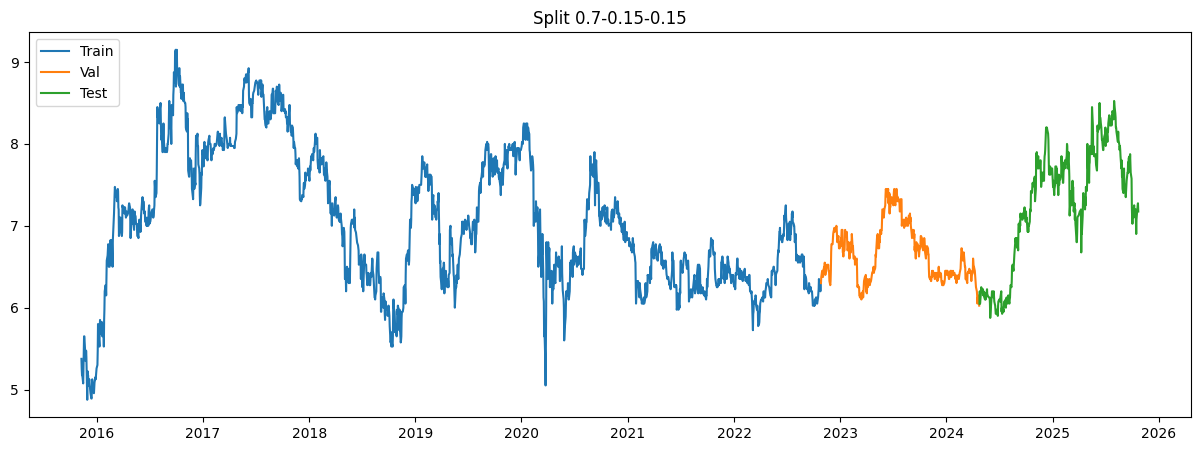

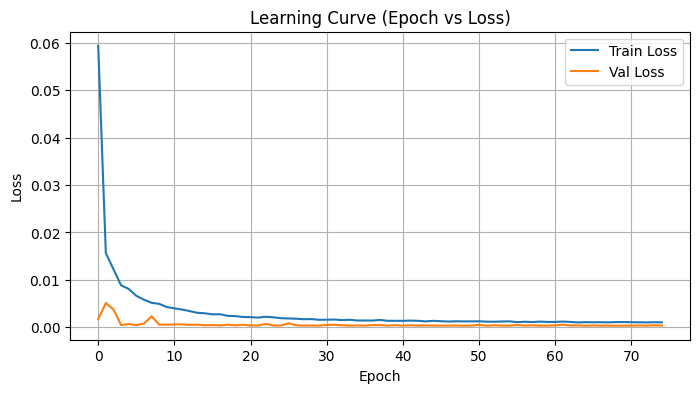

Best epoch: 65

🔥 KOMBINASI 0.8-0.1-0.1
Train: (2077, 12, 1), Val: (259, 12, 1), Test: (261, 12, 1)
Total kombinasi: 16

➡️ Kombinasi 1
MAPE TEST: 1.35%

➡️ Kombinasi 2
MAPE TEST: 1.66%

➡️ Kombinasi 3
MAPE TEST: 1.38%

➡️ Kombinasi 4
MAPE TEST: 2.21%

➡️ Kombinasi 5
MAPE TEST: 1.38%

➡️ Kombinasi 6
MAPE TEST: 1.42%

➡️ Kombinasi 7
MAPE TEST: 1.36%

➡️ Kombinasi 8
MAPE TEST: 1.37%

➡️ Kombinasi 9
MAPE TEST: 1.76%

➡️ Kombinasi 10
MAPE TEST: 1.42%

➡️ Kombinasi 11
MAPE TEST: 2.52%

➡️ Kombinasi 12
MAPE TEST: 1.37%

➡️ Kombinasi 13
MAPE TEST: 1.55%

➡️ Kombinasi 14
MAPE TEST: 1.49%

➡️ Kombinasi 15
MAPE TEST: 1.81%

➡️ Kombinasi 16
MAPE TEST: 1.41%

🏆 BEST PARAMS: (32, 2, (1, 2, 4), 32, 0.1, 8, 0.0001)
BEST MAPE TEST: 1.35%
⏱️ Waktu Split 0.8-0.1-0.1: 653.22 detik


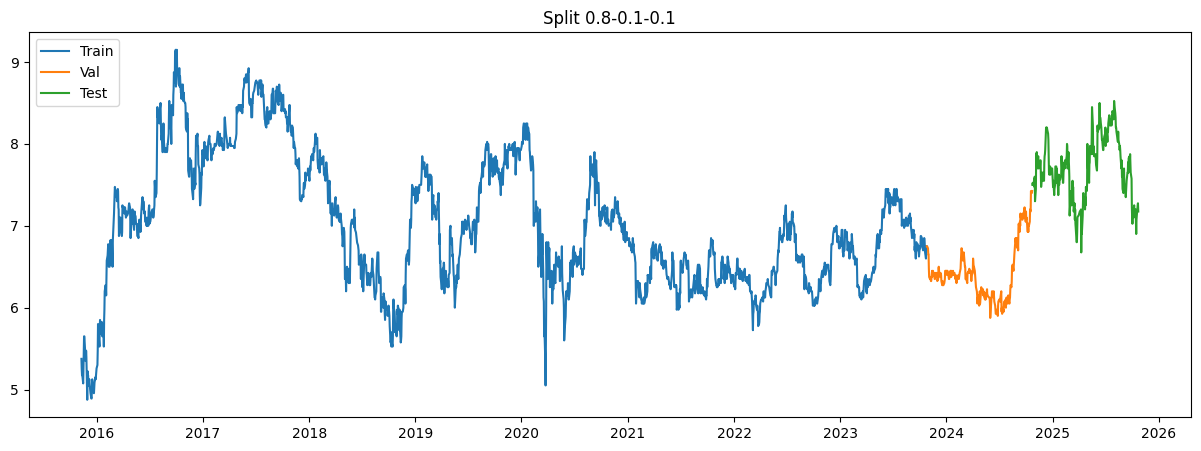

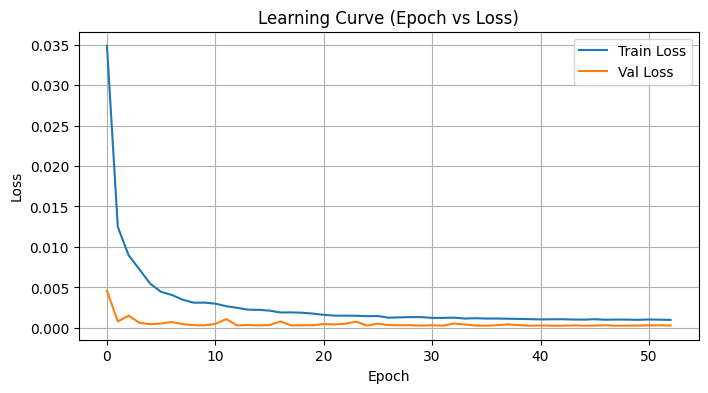

Best epoch: 43

📊 PERBANDINGAN SKENARIO:


,split,best_mape,best_params,best_epoch,training_time_sec
0,0.6-0.2-0.2,1.076642,"(32, 3, (1, 2, 4), 32, 0.1, 16, 0.0001)",57,507.486916
1,0.7-0.15-0.15,1.192153,"(64, 3, (1, 2, 4), 64, 0.1, 16, 0.0001)",65,715.799132
2,0.8-0.1-0.1,1.352698,"(32, 2, (1, 2, 4), 32, 0.1, 8, 0.0001)",43,653.219889



⏱️ Total Running Time: 1876.93 seconds
≈ 31.28 minutes

TABEL 1: HASIL HYPERPARAMETER TUNING (TRAINING)


,Kombinasi Ke-,Split,Filter,Kernel,GRU Units,Batch Size,LR,Best Epoch,Time (sec)
0,1,0.6-0.2-0.2,32,2,32,8,0.0001,16,23.86
1,2,0.6-0.2-0.2,32,2,32,16,0.0001,48,28.39
2,3,0.6-0.2-0.2,32,2,64,8,0.0001,32,39.74
3,4,0.6-0.2-0.2,32,2,64,16,0.0001,65,43.71
4,5,0.6-0.2-0.2,32,3,32,8,0.0001,11,20.35
5,6,0.6-0.2-0.2,32,3,32,16,0.0001,57,36.67
6,7,0.6-0.2-0.2,32,3,64,8,0.0001,27,36.43
7,8,0.6-0.2-0.2,32,3,64,16,0.0001,33,28.40
8,9,0.6-0.2-0.2,64,2,32,8,0.0001,23,42.20
9,10,0.6-0.2-0.2,64,2,32,16,0.0001,14,18.59



TABEL 2: HASIL TESTING FINAL (BEST PARAMS PER SKENARIO)


,split,rmse,mae,mape,r2
0,0.6-0.2-0.2,0.109568,0.077301,1.076642,0.977494
1,0.7-0.15-0.15,0.120758,0.087487,1.192153,0.971878
2,0.8-0.1-0.1,0.137564,0.103387,1.352698,0.869972


In [19]:
# ===============================
# 1. PREPROCESSING
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import time

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Bidirectional, GRU, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input

from tcn import TCN
import itertools

start_time_total = time.time()
tf.random.set_seed(1234)

# ===============================
# 2. SPLIT CONFIG
# ===============================
split_configs = [
    (0.6, 0.2, 0.2),
    (0.7, 0.15, 0.15),
    (0.8, 0.1, 0.1)
]

all_results = []

# ===============================
# 3. HYPERPARAMETER SPACE
# ===============================
tcn_filters = [32, 64]
tcn_kernel_sizes = [2, 3]
tcn_dilations = [(1, 2, 4)]
gru_units = [32, 64]
dropout_rates = [0.1] #tambah
batch_sizes = [8, 16] #tambah 
learning_rates = [0.0001] #tambah

hyperparameter_combinations = list(itertools.product(
    tcn_filters, tcn_kernel_sizes, tcn_dilations,
    gru_units, dropout_rates, batch_sizes, learning_rates
))
tuning_table_data = []
testing_table_data = []

# ===============================
# 4. SEQUENCE HELPER FUNCTION
# ===============================
def make_sequences(scaled, seq_len):
    X, y = [], []
    for i in range(len(scaled) - seq_len):
        X.append(scaled[i:i+seq_len])
        y.append(scaled[i+seq_len])
    return np.array(X), np.array(y)

raw = data[['Terakhir']].values   # data mentah, BELUM discale
sequence_length = 12

# ===============================
# 5. LOOP SPLIT
# ===============================
global_best_mape = float('inf')
global_best_model = None
global_best_split = None
best_history = None
best_metrics = {}

for train_ratio, val_ratio, test_ratio in split_configs:

    best_history = None
    print(f"\n🔥 KOMBINASI {train_ratio}-{val_ratio}-{test_ratio}")
    start_time_split = time.time()

    # ===============================
    # SPLIT DATA
    # ===============================

    # 1. Hitung ukuran split dari data mentah
    n_total = len(raw) - sequence_length   # sama dengan len(X) nanti
    train_size = int(n_total * train_ratio)
    val_size   = int(n_total * val_ratio)

    train_size_raw = train_size + sequence_length  # +12 karena sequence butuh lookback

    # 2. FIT scaler hanya dari data train (mentah)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(raw[:train_size_raw])

    # 3. TRANSFORM semua data pakai scaler yang sama
    scaledDataMat = scaler.transform(raw)

    # 4. Buat sequence SETELAH scaling
    X, y = make_sequences(scaledDataMat, sequence_length)

    # 5. Split X dan y
    X_train = X[:train_size]
    y_train = y[:train_size]

    X_val = X[train_size:train_size+val_size]
    y_val = y[train_size:train_size+val_size]

    X_test = X[train_size+val_size:]
    y_test = y[train_size+val_size:]

    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    # ===============================
    # RESET BEST MODEL
    # ===============================
    results = []
    best_mape = float('inf')
    best_model = None
    best_params = None

    print(f"Total kombinasi: {len(hyperparameter_combinations)}")

    # ===============================
    # LOOP HYPERPARAMETER
    # ===============================
    for i, (tcn_filter, kernel_size, dilations, gru_unit, dropout_rate, batch_size_param, lr) in enumerate(hyperparameter_combinations):
        start_time_comb = time.time()
        split_name = f"{train_ratio}-{val_ratio}-{test_ratio}"
        print(f"\n➡️ Kombinasi {i+1}")

        try:
            tf.keras.backend.clear_session()

            model = Sequential()

            model.add(Input(shape=(sequence_length, 1)))

            model.add(TCN(
                nb_filters=tcn_filter,
                kernel_size=kernel_size,
                dilations=list(dilations),
                return_sequences=True,
                activation='relu',
                # input_shape=(sequence_length, 1),
                padding='causal'
            ))

            model.add(Dropout(dropout_rate))
            model.add(Bidirectional(GRU(units=gru_unit)))
            model.add(Dense(1))

            model.compile(
                optimizer=Adam(learning_rate=lr),
                loss='mse',
                metrics=['mae']
            )

            EPOCHS = 80
            early_stopping = EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True
            )

            history = model.fit(
                X_train, y_train,
                epochs=EPOCHS,
                batch_size=batch_size_param,
                validation_data=(X_val, y_val),
                verbose=0,
                callbacks=[early_stopping]
            )
            end_time_comb = time.time()
            time_comb = end_time_comb - start_time_comb
            best_ep = np.argmin(history.history['val_loss']) + 1

            tuning_table_data.append({
                "Kombinasi Ke-": i + 1,
                "Split": split_name,
                "Filter": tcn_filter,
                "Kernel": kernel_size,
                "GRU Units": gru_unit,
                "Batch Size": batch_size_param,
                "LR": lr,
                "Best Epoch": best_ep,
                "Time (sec)": round(time_comb, 2)
            })

            # ===============================
            # PREDICT
            # ===============================
            y_pred_train = model.predict(X_train, verbose=0)
            y_pred_val = model.predict(X_val, verbose=0)
            y_pred_test = model.predict(X_test, verbose=0)

            # ===============================
            # INVERSE SCALE
            # ===============================
            y_train_ori = scaler.inverse_transform(y_train)
            y_val_ori = scaler.inverse_transform(y_val)
            y_test_ori = scaler.inverse_transform(y_test)

            y_pred_train_ori = scaler.inverse_transform(y_pred_train)
            y_pred_val_ori = scaler.inverse_transform(y_pred_val)
            y_pred_test_ori = scaler.inverse_transform(y_pred_test)

            # ===============================
            # EVALUATION
            # ===============================
            mape_train = mean_absolute_percentage_error(y_train_ori, y_pred_train_ori) * 100
            mape_val = mean_absolute_percentage_error(y_val_ori, y_pred_val_ori) * 100
            mape_test = mean_absolute_percentage_error(y_test_ori, y_pred_test_ori) * 100

            print(f"MAPE TEST: {mape_test:.2f}%")

            results.append([
                tcn_filter, kernel_size, str(dilations), gru_unit,
                dropout_rate, batch_size_param, lr,
                mape_train, mape_val, mape_test
            ])

            # ===============================
            # SAVE BEST MODEL (PER SPLIT)
            # ===============================
            if mape_test < best_mape:
                best_mape = mape_test
                best_model = tf.keras.models.clone_model(model)
                best_model.set_weights(model.get_weights())
                best_params = (tcn_filter, kernel_size, dilations, gru_unit, dropout_rate, batch_size_param, lr)
                best_history = history.history
                best_metrics = {
                    "split": split_name,
                    "rmse": np.sqrt(mean_squared_error(y_test_ori, y_pred_test_ori)),
                    "mae": mean_absolute_error(y_test_ori, y_pred_test_ori),
                    "mape": mape_test,
                    "r2": r2_score(y_test_ori, y_pred_test_ori)
                }

        except Exception as e:
            print("Error:", e)
            continue
    testing_table_data.append(best_metrics)
    # ===============================
    # HASIL PER SPLIT
    # ===============================
    print("\n🏆 BEST PARAMS:", best_params)
    print(f"BEST MAPE TEST: {best_mape:.2f}%")

    end_time_split = time.time()
    split_time = end_time_split - start_time_split

    all_results.append({
        "split": f"{train_ratio}-{val_ratio}-{test_ratio}",
        "best_mape": best_mape,
        "best_params": best_params,
        "best_epoch": np.argmin(best_history['val_loss']) + 1,
        "training_time_sec": split_time
    })

    print(f"⏱️ Waktu Split {train_ratio}-{val_ratio}-{test_ratio}: {split_time:.2f} detik")
    # ===============================
    # SAVE GLOBAL BEST MODEL
    # ===============================
    if best_mape < global_best_mape:
        global_best_mape = best_mape
        global_best_model = best_model
        global_best_split = (train_ratio, val_ratio, test_ratio)
        best_scaler = scaler
        best_scaledDataMat = scaledDataMat

        best_X_train = X_train
        best_X_val = X_val
        best_X_test = X_test

        best_y_train = y_train
        best_y_val = y_val
        best_y_test = y_test

        best_train_size = train_size
        best_val_size = val_size

    # ===============================
    # VISUALISASI
    # ===============================
    start_idx = sequence_length

    train_end = start_idx + train_size
    val_end = train_end + val_size

    data_train = df.iloc[start_idx:train_end]
    data_val = df.iloc[train_end:val_end]
    data_test = df.iloc[val_end:]

    plt.figure(figsize=(15,5))

    plt.plot(data_train['Tanggal'], data_train['Terakhir'], label='Train')
    plt.plot(data_val['Tanggal'], data_val['Terakhir'], label='Val')
    plt.plot(data_test['Tanggal'], data_test['Terakhir'], label='Test')

    plt.title(f"Split {train_ratio}-{val_ratio}-{test_ratio}")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(best_history['loss'], label='Train Loss')
    plt.plot(best_history['val_loss'], label='Val Loss')

    plt.title("Learning Curve (Epoch vs Loss)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

    print("Best epoch:", np.argmin(best_history['val_loss']) + 1)

# ===============================
# 7. RINGKASAN SEMUA SPLIT
# ===============================
summary_df = pd.DataFrame(all_results)
print("\n📊 PERBANDINGAN SKENARIO:")
display(summary_df)

end_time_total = time.time()
total_time = end_time_total - start_time_total

print(f"\n⏱️ Total Running Time: {total_time:.2f} seconds")
print(f"≈ {total_time/60:.2f} minutes")

# Tabel 1: Output Training & Tuning
print("\n" + "="*30)
print("TABEL 1: HASIL HYPERPARAMETER TUNING (TRAINING)")
print("="*30)
df_tuning = pd.DataFrame(tuning_table_data)
display(df_tuning) 

# Tabel 2: Output Testing Final
print("\n" + "="*30)
print("TABEL 2: HASIL TESTING FINAL (BEST PARAMS PER SKENARIO)")
print("="*30)
df_testing = pd.DataFrame(testing_table_data)
# Sesuai permintaan: RMSE, MAE, MAPE, R2
display(df_testing[['split', 'rmse', 'mae', 'mape', 'r2']])

In [20]:
try:
    import tensorflow as tf
    print(f"TensorFlow sudah terinstall (Versi: {tf.__version__})")
except ImportError:
    print("TensorFlow belum ada, memulai instalasi...")
    import sys
    !{sys.executable} -m pip install tensorflow
    import tensorflow as tf
    print("Instalasi selesai!")

TensorFlow sudah terinstall (Versi: 2.21.0)


In [37]:
last_sequence = best_scaledDataMat[-sequence_length:]
last_sequence = last_sequence.reshape(1, sequence_length, 1)

pred = global_best_model.predict(last_sequence)
pred_real = best_scaler.inverse_transform(pred) 

print("Forecast besok:", pred_real[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Forecast besok: 7.209743


In [38]:
# Predict
train_pred = global_best_model.predict(best_X_train)
test_pred = global_best_model.predict(best_X_test)
val_pred = global_best_model.predict(best_X_val)
# Inverse scaling (BALIK KE HARGA ASLI)
train_pred = best_scaler.inverse_transform(train_pred)
test_pred = best_scaler.inverse_transform(test_pred)
val_pred = best_scaler.inverse_transform(val_pred)

y_train_real = best_scaler.inverse_transform(best_y_train)
y_test_real = best_scaler.inverse_transform(best_y_test)
y_val_real = best_scaler.inverse_transform(best_y_val)

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [39]:
import numpy as np

train_plot = np.empty(len(df))
train_plot[:] = np.nan

test_plot = np.empty(len(df))
test_plot[:] = np.nan

In [24]:
# Train
train_plot[sequence_length:best_train_size+sequence_length] = train_pred.flatten()

# Test
test_start = best_train_size + best_val_size + sequence_length
test_plot[test_start:test_start+len(best_y_test)] = test_pred.flatten()

# Validation
val_start = best_train_size + sequence_length
val_plot = np.empty(len(df))
val_plot[:] = np.nan
val_plot[val_start:val_start+len(val_pred)] = val_pred.flatten()

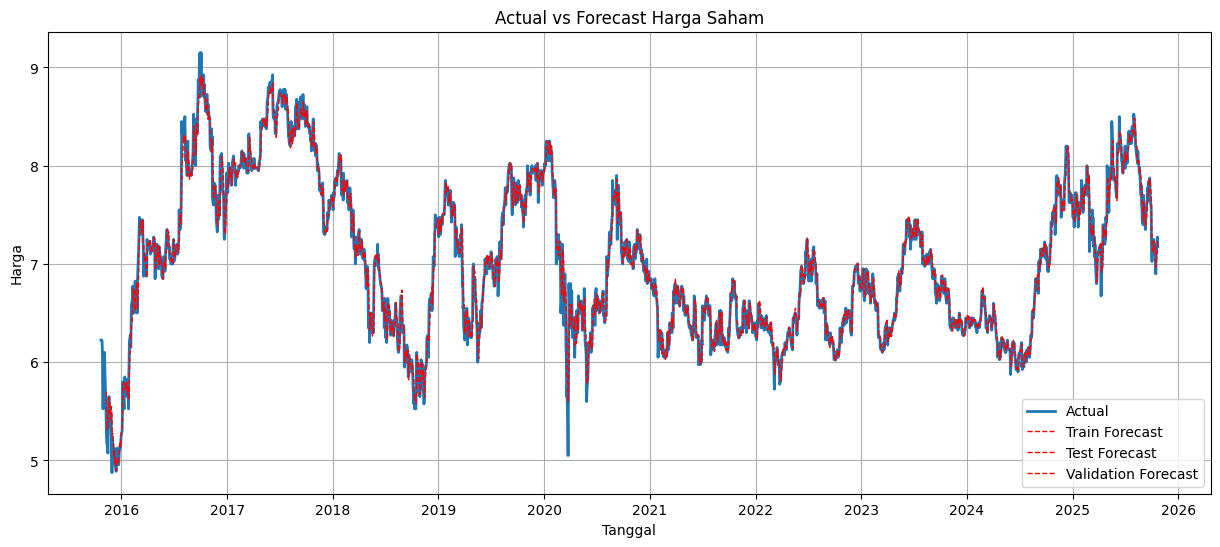

In [25]:
# ganti : grafik actual dan forecast aja (2 line only)
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

# Actual (DATA ASLI)
plt.plot(df['Tanggal'], df['Terakhir'], label='Actual', linewidth=2)

# Forecast
plt.plot(df['Tanggal'], train_plot, label='Train Forecast', color='red', linestyle='--', linewidth=1)
plt.plot(df['Tanggal'], test_plot, label='Test Forecast', color='red', linestyle='--', linewidth=1)
plt.plot(df['Tanggal'], val_plot, label='Validation Forecast', color='red', linestyle='--', linewidth=1)

plt.title("Actual vs Forecast Harga Saham")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.legend()
plt.grid()

plt.show()

In [26]:
df_plot = df.copy()

# WAJIB: sort berdasarkan tanggal
df_plot['Tanggal'] = pd.to_datetime(df_plot['Tanggal'])
df_plot = df_plot.sort_values(by='Tanggal').reset_index(drop=True)
df_plot['Forecast'] = np.nan

# CARA BERSIH (Gunakan .iloc dengan index baris dan index kolom)
# index kolom 'Forecast' bisa didapat dengan df_plot.columns.get_loc('Forecast')
col_idx = df_plot.columns.get_loc('Forecast')

# Masukin train
df_plot.iloc[sequence_length:best_train_size+sequence_length, col_idx] = train_pred.flatten()

# Masukin test
df_plot.iloc[test_start:test_start+len(test_pred), col_idx] = test_pred.flatten()

# Masukin validation
val_idx_start = best_train_size + sequence_length
df_plot.iloc[val_idx_start : val_idx_start + len(val_pred), col_idx] = val_pred.flatten()

last_14 = df_plot.tail(30)

# next business day (biar gak kena weekend)
next_date = df['Tanggal'].iloc[-1] + pd.offsets.BDay(1)
next_value = pred_real[0][0]

In [27]:
# print(y_pred_test_ori[:10])
# print(y_test_ori[:10])

print(test_pred[:10])       # prediksi best model (sudah di-inverse di cell 17)
print(y_test_real[:10])     # aktual best model (sudah di-inverse di cell 17)

[[6.7366347]
 [6.74088  ]
 [6.7506   ]
 [6.744679 ]
 [6.6702046]
 [6.645117 ]
 [6.5359945]
 [6.415433 ]
 [6.367268 ]
 [6.363434 ]]
[[6.75 ]
 [6.75 ]
 [6.725]
 [6.65 ]
 [6.65 ]
 [6.475]
 [6.375]
 [6.35 ]
 [6.375]
 [6.35 ]]


In [41]:
rmse = np.sqrt(mean_squared_error(y_test_real, test_pred))
mae = mean_absolute_error(y_test_real, test_pred)
r2 = r2_score(y_test_real, test_pred)
mape = mean_absolute_percentage_error(y_test_real, test_pred) * 100

print(f"RMSE (Best Model)     : {rmse:.4f}")
print(f"MAE (Best Model)      : {mae:.4f}")
print(f"R² Score (Best Model) : {r2:.4f}")
print(f"MAPE (Best Model)     : {mape:.4f}%")
print(f"Forecast H+1          : Rp {pred_real[0][0]:,.2f}")

RMSE (Best Model)     : 0.1096
MAE (Best Model)      : 0.0773
R² Score (Best Model) : 0.9775
MAPE (Best Model)     : 1.0766%
Forecast H+1          : Rp 7.21


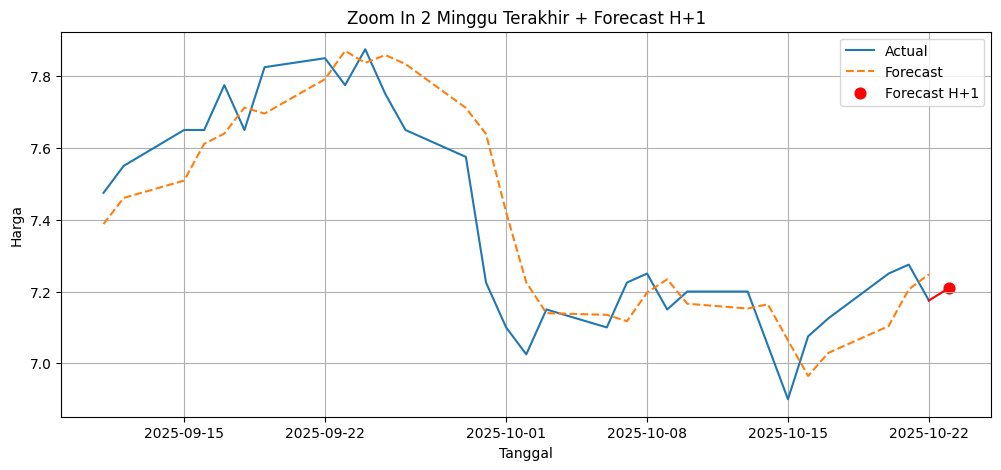

In [29]:
plt.figure(figsize=(12,5))

# actual
plt.plot(last_14['Tanggal'], last_14['Terakhir'], 
         label='Actual')

# forecast (overlap sama actual)
plt.plot(last_14['Tanggal'], last_14['Forecast'], 
         label='Forecast', linestyle='--')

# titik forecast H+1
plt.scatter(next_date, next_value, 
            color='red', label='Forecast H+1', s=60)

# garis bantu ke H+1
plt.plot([last_14['Tanggal'].iloc[-1], next_date],
         [last_14['Terakhir'].iloc[-1], next_value], color='red')

plt.title("Zoom In 2 Minggu Terakhir + Forecast H+1")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.legend()
plt.grid()

plt.show()

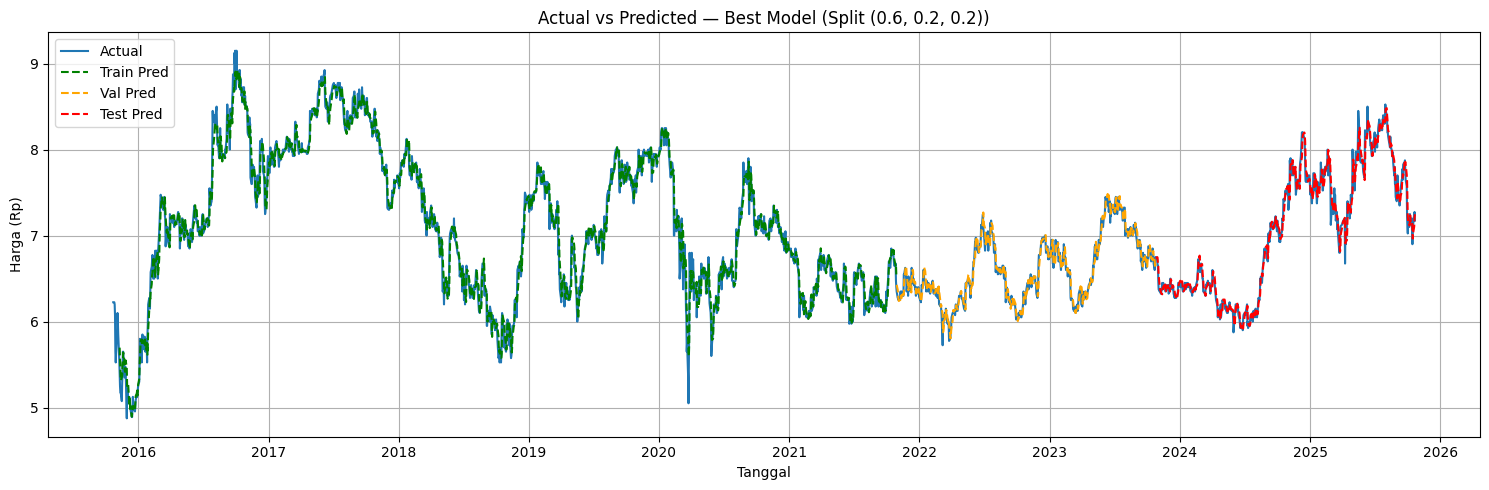

In [30]:
# Actual vs Predicted — seluruh periode
plt.figure(figsize=(15, 5))
plt.plot(df['Tanggal'], df['Terakhir'], label='Actual', linewidth=1.5)
plt.plot(df['Tanggal'], train_plot, label='Train Pred', color='green',  linestyle='--')
plt.plot(df['Tanggal'], val_plot,   label='Val Pred',   color='orange', linestyle='--')
plt.plot(df['Tanggal'], test_plot,  label='Test Pred',  color='red',    linestyle='--')
plt.title(f'Actual vs Predicted — Best Model (Split {global_best_split})')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Rp)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [31]:
print("\nTABEL 4: TRAIN vs VAL vs TEST METRICS (GLOBAL BEST MODEL)")
train_pred = global_best_model.predict(best_X_train, verbose=0)
val_pred   = global_best_model.predict(best_X_val, verbose=0)
test_pred  = global_best_model.predict(best_X_test, verbose=0)

train_pred_ori = best_scaler.inverse_transform(train_pred)
val_pred_ori   = best_scaler.inverse_transform(val_pred)
# test_pred_ori  = best_scaler.inverse_transform(best_y_test)
y_train_ori    = best_scaler.inverse_transform(best_y_train)
y_val_ori      = best_scaler.inverse_transform(best_y_val)
y_test_ori     = best_scaler.inverse_transform(best_y_test)

test_pred_ori  = best_scaler.inverse_transform(
                     global_best_model.predict(best_X_test, verbose=0))

detail_metrics = pd.DataFrame([
    {
        "Data": "Train",
        "RMSE": np.sqrt(mean_squared_error(y_train_ori, train_pred_ori)),
        "MAE":  mean_absolute_error(y_train_ori, train_pred_ori),
        "MAPE": mean_absolute_percentage_error(y_train_ori, train_pred_ori) * 100,
        "R²":   r2_score(y_train_ori, train_pred_ori)
    },
    {
        "Data": "Validasi",
        "RMSE": np.sqrt(mean_squared_error(y_val_ori, val_pred_ori)),
        "MAE":  mean_absolute_error(y_val_ori, val_pred_ori),
        "MAPE": mean_absolute_percentage_error(y_val_ori, val_pred_ori) * 100,
        "R²":   r2_score(y_val_ori, val_pred_ori)
    },
    {
        "Data": "Test",
        "RMSE": np.sqrt(mean_squared_error(y_test_ori, test_pred_ori)),
        "MAE":  mean_absolute_error(y_test_ori, test_pred_ori),
        "MAPE": mean_absolute_percentage_error(y_test_ori, test_pred_ori) * 100,
        "R²":   r2_score(y_test_ori, test_pred_ori)
    }
])
display(detail_metrics)




TABEL 4: TRAIN vs VAL vs TEST METRICS (GLOBAL BEST MODEL)


,Data,RMSE,MAE,MAPE,R²
0,Train,0.131978,0.095209,1.365344,0.976488
1,Validasi,0.083470,0.063295,0.960027,0.950282
2,Test,0.109568,0.077301,1.076642,0.977494


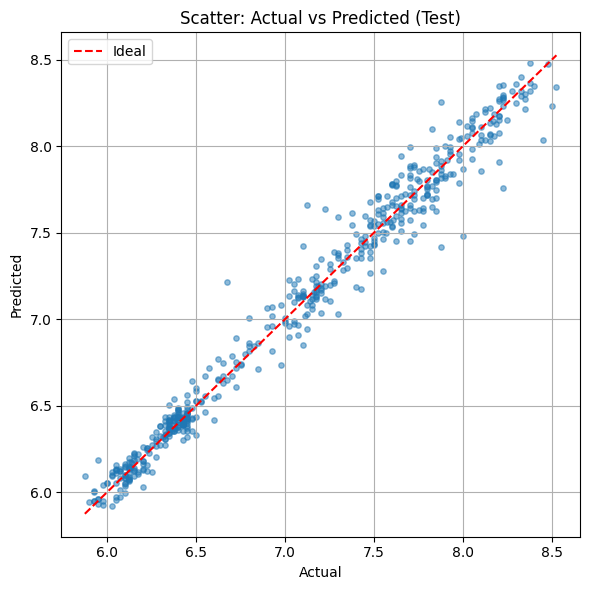

In [32]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_ori, test_pred_ori, alpha=0.5, s=15)
min_val = min(y_test_ori.min(), test_pred_ori.min())
max_val = max(y_test_ori.max(), test_pred_ori.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Scatter: Actual vs Predicted (Test)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

FORECAST 30 HARI KE DEPAN:


,Hari Ke-,Tanggal,Forecast Harga
0,1,2025-10-23,7.210
1,2,2025-10-24,7.190
2,3,2025-10-27,7.223
3,4,2025-10-28,7.222
4,5,2025-10-29,7.227
5,6,2025-10-30,7.243
6,7,2025-10-31,7.241
7,8,2025-11-03,7.256
8,9,2025-11-04,7.253
9,10,2025-11-05,7.263


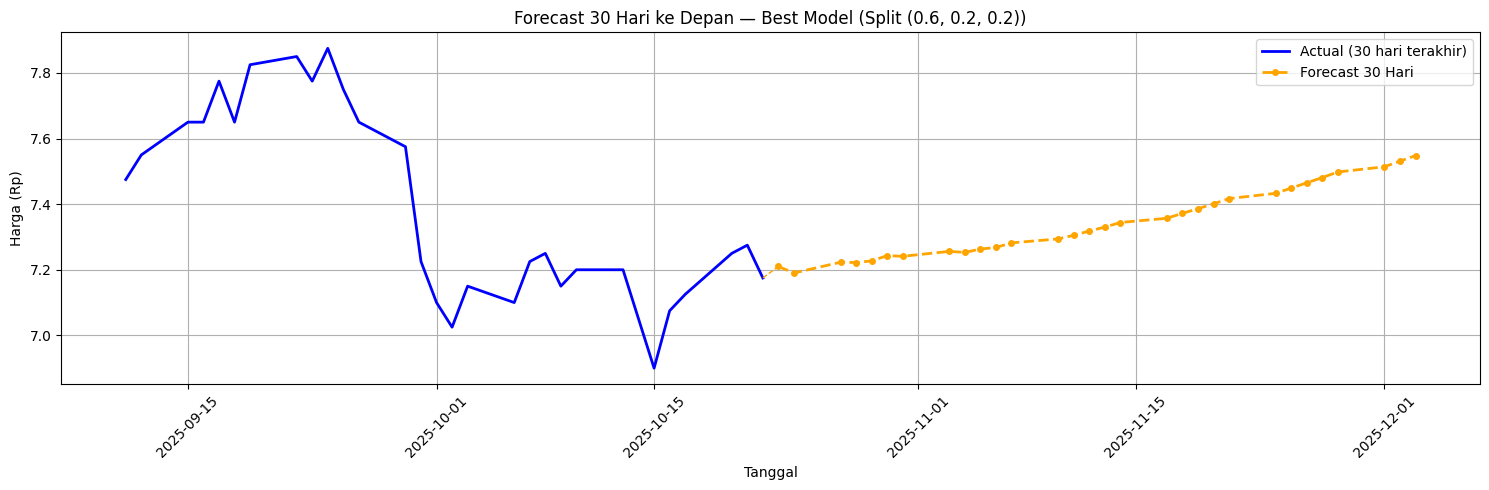


Harga Aktual Terakhir  : Rp 7.175
Forecast Hari ke-1     : Rp 7.210
Forecast Hari ke-30    : Rp 7.548


In [45]:
# ===============================
# FORECAST 30 HARI KE DEPAN
# ===============================
forecast_days = 30
forecast_results = []

# Mulai dari sequence terakhir milik best split
current_sequence = best_scaledDataMat[-sequence_length:].copy()  # shape: (12, 1)

for day in range(forecast_days):
    # Reshape jadi (1, 12, 1) untuk input model
    input_seq = current_sequence.reshape(1, sequence_length, 1)
    
    # Prediksi 1 hari ke depan
    pred_scaled = global_best_model.predict(input_seq, verbose=0)
    
    # Inverse transform ke harga asli
    pred_price = best_scaler.inverse_transform(pred_scaled)[0][0]
    
    # Simpan tanggal dan harga prediksi
    next_date = df['Tanggal'].iloc[-1] + pd.offsets.BDay(day + 1)
    forecast_results.append({
        "Hari Ke-": day + 1,
        "Tanggal": next_date.strftime('%Y-%m-%d'),
        "Forecast Harga": round(pred_price, 3)
    })
    
    # Update sequence: geser 1, masukkan prediksi terbaru
    current_sequence = np.roll(current_sequence, -1, axis=0)
    current_sequence[-1] = pred_scaled[0]

# Tampilkan tabel
df_forecast = pd.DataFrame(forecast_results)
print("FORECAST 30 HARI KE DEPAN:")
display(df_forecast)

# ===============================
# VISUALISASI FORECAST 30 HARI
# ===============================
# Ambil 30 hari terakhir data aktual sebagai konteks
last_actual = df.tail(30).copy()

forecast_dates = pd.to_datetime(df_forecast['Tanggal'])
forecast_prices = df_forecast['Forecast Harga']

plt.figure(figsize=(15, 5))

# Data aktual (30 hari terakhir sebagai konteks)
plt.plot(last_actual['Tanggal'], last_actual['Terakhir'], 
         label='Actual (30 hari terakhir)', color='blue', linewidth=2)

# Garis penghubung actual → forecast
plt.plot([last_actual['Tanggal'].iloc[-1], forecast_dates.iloc[0]],
         [last_actual['Terakhir'].iloc[-1], forecast_prices.iloc[0]],
         color='orange', linestyle='--', linewidth=1)

# Forecast 30 hari
plt.plot(forecast_dates, forecast_prices, 
         label='Forecast 30 Hari', color='orange', linestyle='--', linewidth=2, marker='o', markersize=4)

plt.title(f'Forecast 30 Hari ke Depan — Best Model (Split {global_best_split})')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Rp)')
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nHarga Aktual Terakhir  : Rp {df['Terakhir'].iloc[-1]:,.3f}")
print(f"Forecast Hari ke-1     : Rp {df_forecast['Forecast Harga'].iloc[0]:,.3f}")
print(f"Forecast Hari ke-30    : Rp {df_forecast['Forecast Harga'].iloc[-1]:,.3f}")

In [48]:
import pickle

# Simpan semua hasil yang dibutuhkan
results_to_save = {
    # Metrik
    "rmse":  rmse,
    "mae":   mae,
    "mape":  mape,
    "r2":    r2,
    # Forecast H+1
    "forecast_h1": pred_real[0][0],
    # Forecast 30 hari
    "forecast_30_dates":  df_forecast['Tanggal'].tolist(),
    "forecast_30_prices": df_forecast['Forecast Harga'].tolist(),
    # Info tambahan
    "best_split": global_best_split,
    "last_actual_price": df['Terakhir'].iloc[-1],
    "last_actual_date":  df['Tanggal'].iloc[-1],
    # total time
    "total_time":       total_time,
    "tuning_times":     df_tuning["Time (sec)"].tolist(), 
}

# Ganti nama file sesuai notebook-nya
pickle.dump(results_to_save, open("results_tcn_bigru.pkl", "wb"))   # di notebook TCN-BiGRU
print("✅ Hasil disimpan!")

✅ Hasil disimpan!
